# 02 — Customer Segmentation (Personas)
### SmartTel Retention Intelligence — Module 2

**Input:** `telco_features_latest.parquet` (produced by `01_eda_and_data_quality.ipynb`)

**Scope of this notebook** (Module 2 of the proposal):
1. Load the feature-store dataset
2. Select and prepare features for clustering (mixed categorical/numeric)
3. Fit K-Prototypes across a range of *k*, choose *k* using an elbow (cost) curve and an approximate silhouette check
4. Fit the final model and profile each cluster
5. Assign interpretable, data-driven persona names
6. Compute churn rate **within each persona** — the key insight this module must produce
7. Persist the persona-labeled dataset back to the feature store

> **Why K-Prototypes, not plain KMeans:** most fields in this dataset are categorical (`Contract`, `InternetService`, `PaymentMethod`, etc.), and KMeans' Euclidean distance isn't meaningful on unordered categories. K-Prototypes combines Euclidean distance for numeric fields with a matching-dissimilarity measure for categorical fields, which fits this dataset's structure directly.


Import abd setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date

from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

FEATURE_STORE_DIR = Path("../data/feature_store")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Load Feature-Store Dataset

In [3]:
df = pd.read_parquet(FEATURE_STORE_DIR / "telco_features_latest.parquet")
#print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket,services_count,avg_monthly_revenue,contract_risk_flag
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6mo,1,29.850000,1
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48mo,3,55.573529,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6mo,3,54.075000,0
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48mo,3,40.905556,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6mo,1,75.825000,1


This is the cleaned, feature-engineered output of Module 1: `TotalCharges` blanks imputed, `SeniorCitizen` normalized to Yes/No, and `tenure_bucket`, `services_count`, `avg_monthly_revenue`, and `contract_risk_flag` already added.


## 3. Feature Selection for Clustering

** Features excluded from clustering, and why:**
- `customerID` — identifier, not a feature
- `Churn` — the target. Clustering on the label would make "churn rate by persona" circular; personas must be discoverable independently of the outcome we later measure against them
- `TotalCharges` — confirmed in Module 1 to correlate >0.99 with `tenure × MonthlyCharges`; including it would let billing history dominate the distance metric with information already captured by `tenure` and `MonthlyCharges`
- `avg_monthly_revenue` — derived from `TotalCharges`/`tenure`; kept for later profiling but dropped from the clustering distance to avoid double-weighting tenure and spend
- `tenure_bucket` — a discretized version of `tenure`; keeping both would double-count the same signal in a mixed-distance metric. The continuous `tenure` is used for clustering; `tenure_bucket` is kept for readable profiling afterward
- `contract_risk_flag` — derived directly from `Contract` and `PaymentMethod`, both of which are already included; would triple-count that signal

**Numeric features used:** `tenure`, `MonthlyCharges`, `services_count`

**Categorical features used:** all remaining service, account, and demographic fields (16 columns)


In [4]:
numeric_features = ["tenure", "MonthlyCharges", "services_count"]

categorical_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod",
]
cluster_cols = numeric_features + categorical_features
print(len(cluster_cols))

19


#### checking for missing values

In [5]:
X = df[cluster_cols].copy()
X.isnull().sum().sum()  # sanity check: should be 0, already cleaned in Module 1

np.int64(0)

## 4. Data Preprocessing

Numeric features are standardized (zero mean, unit variance) so that `tenure` (range ~0–72) and `MonthlyCharges` (range ~18–120) contribute comparably to the Euclidean portion of the K-Prototypes distance, rather than the larger-magnitude feature dominating by scale alone.

K-Prototypes requires numeric columns first, followed by categorical columns, with the categorical column *indices* passed explicitly, the cell below prepares that layout.


In [6]:
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

# K-Prototypes needs categorical columns as strings and their positional indices
for col in categorical_features:
    X_scaled[col] = X_scaled[col].astype(str)

categorical_indices = [X_scaled.columns.get_loc(c) for c in categorical_features] # get categorical column positions
X_matrix = X_scaled.to_numpy() #convert to matrix for k-prototypes

print(f"Matrix shape: {X_matrix.shape}")
print(f"Categorical column indices: {categorical_indices}")


Matrix shape: (7043, 19)
Categorical column indices: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


## 5. Choosing the Number of Personas (k)

Two checks are used together, since neither is fully sufficient on its own for mixed-type data:

1. **Elbow curve on K-Prototypes cost** — the native cost function (sum of numeric Euclidean distances + weighted categorical mismatches) across candidate *k* values
2. **Approximate silhouette score** — true silhouette isn't natively defined for K-Prototypes' mixed distance metric, so this is computed on a **one-hot-encoded, scaled representation** of the same features as a numeric proxy, on a random subsample for tractability. This is a heuristic cross-check, not an exact validation — treated as directional, alongside the elbow curve and the interpretability of the resulting personas.

The proposal targets **4–6 personas**, so *k* is chosen from that range.


In [7]:
candidate_ks = list(range(3, 8))
costs = []
models = {}

for k in candidate_ks:
    kproto = KPrototypes(n_clusters=k, init="Cao", n_init=3, random_state=RANDOM_SEED, verbose=0)
    labels = kproto.fit_predict(X_matrix, categorical=categorical_indices)
    costs.append(kproto.cost_)
    models[k] = (kproto, labels)
    print(f"k={k}  cost={kproto.cost_:,.1f}")


k=3  cost=24,408.0
k=4  cost=22,014.6
k=5  cost=20,626.5
k=6  cost=19,118.3
k=7  cost=18,246.3


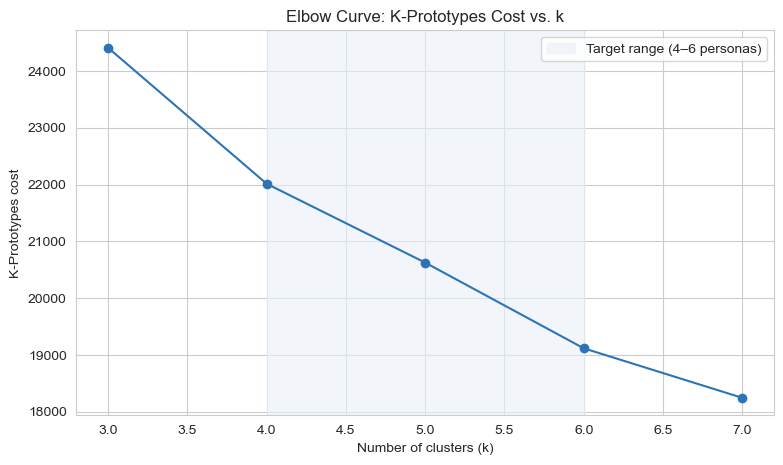

In [8]:
fig, ax = plt.subplots()
ax.plot(candidate_ks, costs, marker="o", color="#2E74B5")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("K-Prototypes cost")
ax.set_title("Elbow Curve: K-Prototypes Cost vs. k")
ax.axvspan(4, 6, color="#EAF1F8", alpha=0.6, label="Target range (4–6 personas)")
ax.legend()
plt.show()


In [9]:
# One-hot encoded, scaled representation for an approximate silhouette check
X_ohe = pd.get_dummies(X[categorical_features], drop_first=False)
X_ohe_full = pd.concat(
    [pd.DataFrame(scaler.transform(X[numeric_features]), columns=numeric_features, index=X.index), X_ohe],
    axis=1,
)

# Subsample for tractability (silhouette is O(n^2) in memory/time)
sample_idx = X_ohe_full.sample(n=2000, random_state=RANDOM_SEED).index

sil_scores = {}
for k in candidate_ks:
    _, labels = models[k]
    labels_sample = pd.Series(labels, index=X.index).loc[sample_idx]
    score = silhouette_score(X_ohe_full.loc[sample_idx], labels_sample)
    sil_scores[k] = score
    print(f"k={k}  approx. silhouette={score:.4f}")


k=3  approx. silhouette=0.2290
k=4  approx. silhouette=0.1774
k=5  approx. silhouette=0.1771
k=6  approx. silhouette=0.1359
k=7  approx. silhouette=0.1212


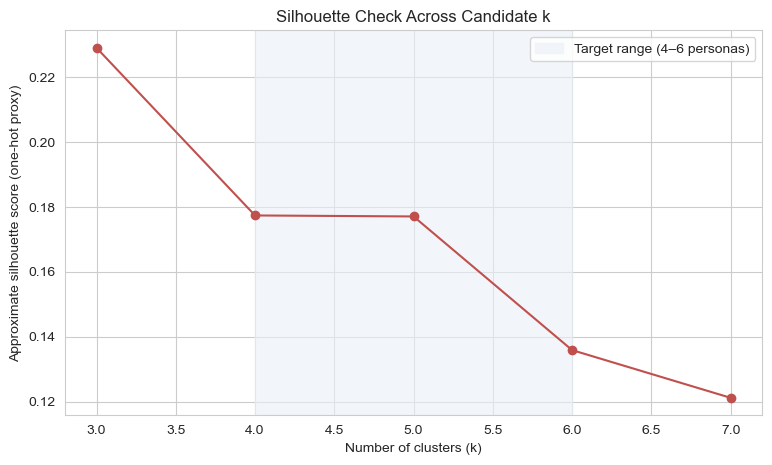

In [10]:
fig, ax = plt.subplots()
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o", color="#C0504D")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Approximate silhouette score (one-hot proxy)")
ax.set_title("Silhouette Check Across Candidate k")
ax.axvspan(4, 6, color= "#EAF1F8", alpha=0.6, label="Target range (4–6 personas)")
ax.legend()
plt.show()


 Between 4 and 5 clusters, the score stays completely flat at approximately 0.18. This means adding a fifth cluster does not degrade the structural quality of the groupings.

In [11]:
target_range = [4, 5, 6]  
sil_scores_in_range = {k: v for k, v in sil_scores.items() if k in target_range}

best_k = max(sil_scores_in_range, key=sil_scores_in_range.get)
print(f"Approximate silhouette scores within the target range: {sil_scores_in_range}")
print(f"Selected k (highest silhouette within 4-6): {best_k}")
print(f"Cost at that k: {dict(zip(candidate_ks, costs))[best_k]:,.1f}")


Approximate silhouette scores within the target range: {4: 0.17740908698562627, 5: 0.17709997557624263, 6: 0.13592825163464387}
Selected k (highest silhouette within 4-6): 4
Cost at that k: 22,014.6


## 6. Fit Final Model & Assign Personas

In [12]:
final_k = best_k
final_model, final_labels = models[final_k]

df["persona_id"] = final_labels
print(f"Final number of personas: {final_k}")
df["persona_id"].value_counts().sort_index()


Final number of personas: 4


persona_id
0    1555
1    1817
2    1552
3    2119
Name: count, dtype: int64